# Sudan's Climate: Basic Exploration

## Step 1: Importing the Data

In this step, we load the required datasets using Pandas and NumPy and perform an initial inspection of the Sudan climate dataset.


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/sudan.csv")
df["Country"] = "Sudan"
df["date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["date"].dt.month
df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


## Step 2: Cleaning the Data

This step involves handling missing values, correcting data types, removing inconsistencies, and preparing the dataset for analysis.


In [2]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52,Sudan,2026-03-27,3
4104,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,Sudan,2026-03-28,3
4105,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,Sudan,2026-03-29,3
4106,2026,89,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18,Sudan,2026-03-30,3


In [3]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()


Duplicate rows: 0


In [4]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "missing": missing,
    "percent": missing_pct
})

missing_df

,missing,percent
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [6]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy='omit'))

outliers = (z_scores > 3).sum()
print(outliers)

91


In [7]:
# Drop rows with >30% missing
threshold = int(df.shape[1] * 0.7)
df = df.dropna(thresh=threshold)

# Forward fill
df.ffill()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52,Sudan,2026-03-27,3
4104,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,Sudan,2026-03-28,3
4105,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,Sudan,2026-03-29,3
4106,2026,89,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18,Sudan,2026-03-30,3


In [8]:
df.to_csv("../data/sudan_clean.csv", index=False)

## Step 3: Exploration of the Data

We analyze Sudan’s climate data to identify patterns, trends, and seasonal behavior across the years.


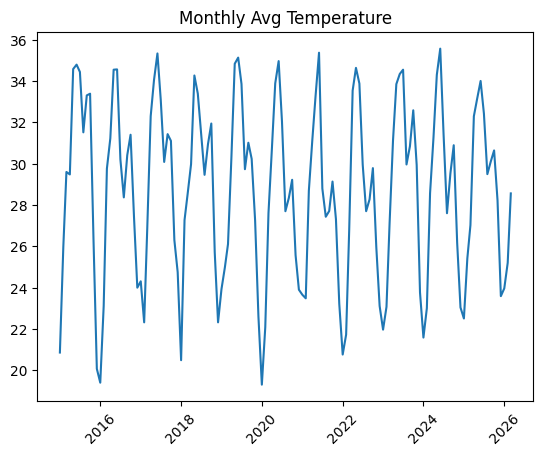

In [9]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()

monthly_temp["date"] = pd.to_datetime(
    monthly_temp["YEAR"].astype(str) + "-" + monthly_temp["Month"].astype(str)
)

plt.figure()
plt.plot(monthly_temp["date"], monthly_temp["T2M"])
plt.title("Monthly Avg Temperature")
plt.xticks(rotation=45)
plt.show()

## Interpretation 1: Monthly Average Temperature (2015–2026)

The analysis of Sudan’s monthly average temperature from 2015 to 2026 shows very high temperature levels compared to the other countries analyzed, including Tanzania.

Overall, Sudan reaches extremely high temperatures, with peaks close to **36°C**, making it one of the hottest datasets in the comparison. This indicates a predominantly hot climate with limited cooling periods.

The **lowest temperature occurs around 2020**, while another relatively low point is observed around **2016**, particularly at the beginning of the year. This pattern is similar to Ethiopia, where the lowest temperatures tend to occur at the start of the year, suggesting a seasonal cooling effect during early months.

Across individual years, the **highest monthly temperatures remain relatively stable**, showing little variation in peak values over time. However, the **lowest temperatures within each year fluctuate more noticeably**, alternating between increases and decreases.

Despite this, there is a clear long-term pattern: from **2016 to 2026, Sudan’s overall monthly average temperature shows an upward trend**, with especially noticeable warming in 2026. The early months of 2026, which previously represented the lowest temperature periods in earlier years, are significantly warmer compared to previous years.

In summary, Sudan’s temperature pattern is characterized by:
- Very high overall temperatures (up to ~36°C)  
- Lowest temperatures around 2016 and 2020  
- Stable peak temperatures across years  
- A clear long-term warming trend, especially by 2026  
- Strong seasonal influence with early-year temperature dips in earlier years becoming less pronounced over time  

<Figure size 640x480 with 0 Axes>

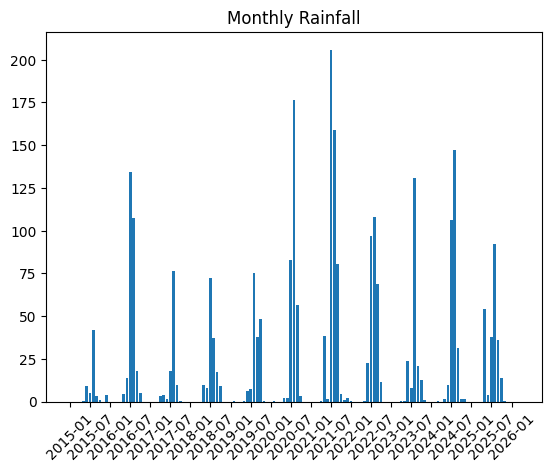

In [10]:
monthly_rain = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()
plt.figure()
monthly_rain = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()

# Create a label column for the x-axis
monthly_rain["label"] = monthly_rain["YEAR"].astype(str) + "-" + monthly_rain["Month"].astype(str).str.zfill(2)

plt.figure()
plt.bar(monthly_rain["label"], monthly_rain["PRECTOTCORR"])

step = 6
plt.xticks(
    ticks=range(0, len(monthly_rain), step),
    labels=monthly_rain["label"][::step],
    rotation=45
)

plt.title("Monthly Rainfall")
plt.show()

## Interpretation 2: Monthly Rainfall Patterns (2015–2026)

The monthly rainfall data for Sudan shows strong variability with alternating increases and decreases over the years, along with significant differences between minimum and maximum monthly values.

The **highest rainfall is recorded around 2021**, with values slightly above 200 mm. While this is lower compared to Tanzania’s extreme rainfall levels, it still represents the peak rainfall period in Sudan’s dataset.

Overall, rainfall shows a pattern of **increase → decrease → increase cycles**, suggesting that precipitation levels fluctuate significantly over time rather than following a stable trend. This may reflect alternating wet and dry climate phases.

Within individual years, rainfall variability is also very high. The **lowest rainfall values are close to zero**, while the **highest values reach around 150–200 mm**, indicating strong differences between dry and wet months even within the same year.

The pattern suggests that Sudan’s rainfall system is highly inconsistent, with:
- A peak rainfall period around 2021  
- Repeating cycles of increase and decrease over time  
- Very large differences between dry and wet months  
- Frequent near-zero rainfall periods  
- No stable long-term rainfall trend  

This indicates that Sudan experiences strong rainfall variability influenced by seasonal and interannual climate changes rather than a consistent precipitation pattern.

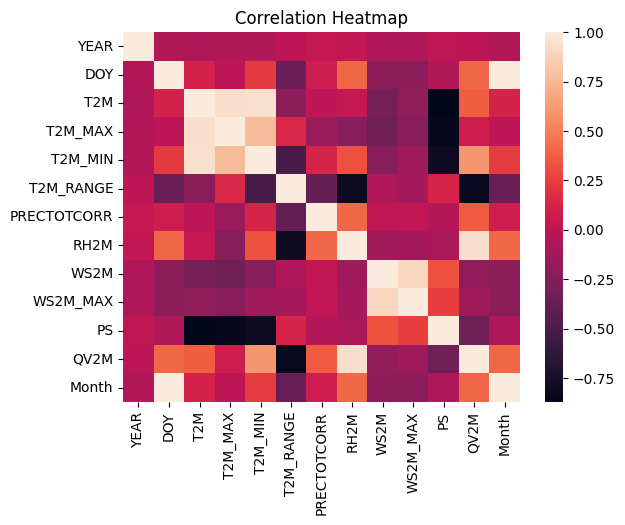

In [11]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=False)
plt.title("Correlation Heatmap")
plt.show()

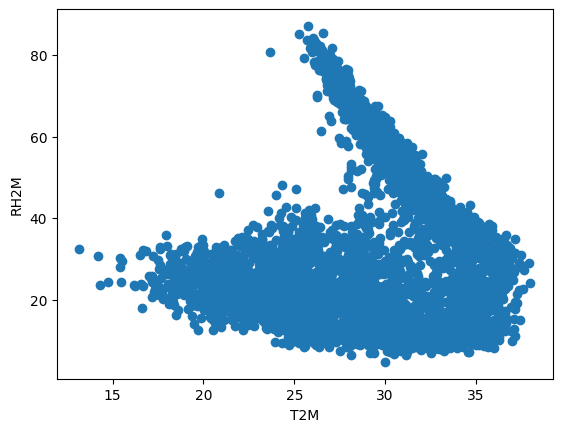

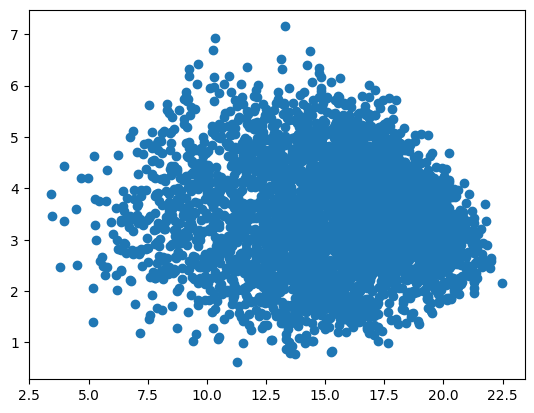

In [12]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.show()

df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

plt.figure()
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.show()

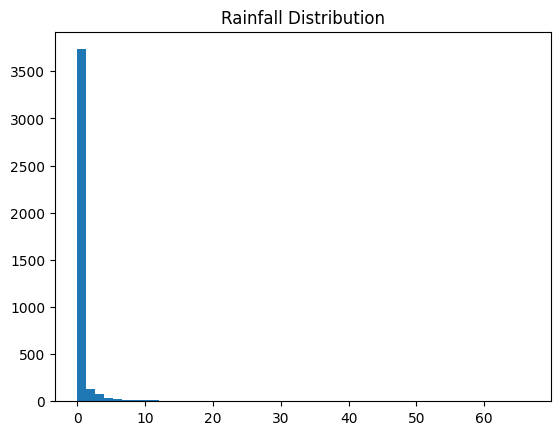

In [13]:
plt.figure()
plt.hist(df["PRECTOTCORR"].dropna(), bins=50)
plt.title("Rainfall Distribution")
plt.show()

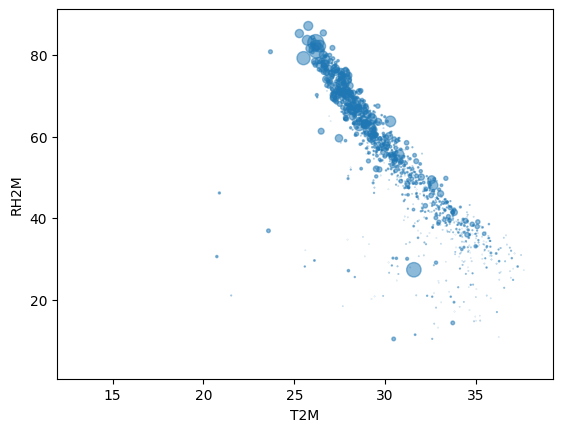

In [14]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.show()